# Descrição do Projeto

A empresa Sweet Lift Taxi coletou dados históricos sobre pedidos de táxi nos aeroportos. Para atrair mais motoristas durante o horário de pico, precisamos prever a quantidade de pedidos de táxi para a próxima hora. 	
Construa um modelo para tal predição.

A métrica REQM no conjunto de teste não deve ser superior a 48.

## Instruções do projeto

1. Faça download dos dados e faça uma nova amostragem em uma hora.
2. Analise os dados
3. Treine diferentes modelos com diferentes hiperparâmetros. A amostra de teste deve ser 10% do conjunto de dados inicial.
4. Teste os dados usando a amostra de teste e forneça uma conclusão.

## Descrição dos dados

Os dados são armazenados no arquivo `taxi.csv`. O número de pedidos está na coluna `num_orders`.

## Preparação 

### Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

### Baixando os dados

In [2]:
df = pd.read_csv('datasets/taxi.csv')

### Visão geral dos dados

In [3]:
df.info()

df.sample(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   datetime    26496 non-null  object
 1   num_orders  26496 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 414.1+ KB


,datetime,num_orders
2460,2018-03-18 02:00:00,6
12673,2018-05-28 00:10:00,26
7655,2018-04-23 03:50:00,19
14497,2018-06-09 16:10:00,14
13034,2018-05-30 12:20:00,8
2016,2018-03-15 00:00:00,20
1522,2018-03-11 13:40:00,9
4663,2018-04-02 09:10:00,4
15375,2018-06-15 18:30:00,7
9157,2018-05-03 14:10:00,8


### Transformando em série temporal

In [4]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [5]:
df = df.set_index('datetime')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


### Reamostragem com intervalos de uma hora

In [7]:
df = df.resample('1H').sum()

C:\Users\joaod\AppData\Local\Temp\ipykernel_18512\1649191478.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.resample('1H').sum()


## Análise

### Análise inicial

In [8]:
display(df.head(), df.tail())
print('Período:', df.index.min(), '→', df.index.max())
print('Intervalo total:', df.index.max() - df.index.min())
print('Frequências observadas:\n', df.index.to_series().diff().value_counts().head())

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


,num_orders
datetime,
2018-08-31 19:00:00,136
2018-08-31 20:00:00,154
2018-08-31 21:00:00,159
2018-08-31 22:00:00,223
2018-08-31 23:00:00,205


Período: 2018-03-01 00:00:00 → 2018-08-31 23:00:00
Intervalo total: 183 days 23:00:00
Frequências observadas:
 datetime
0 days 01:00:00    4415
Name: count, dtype: int64


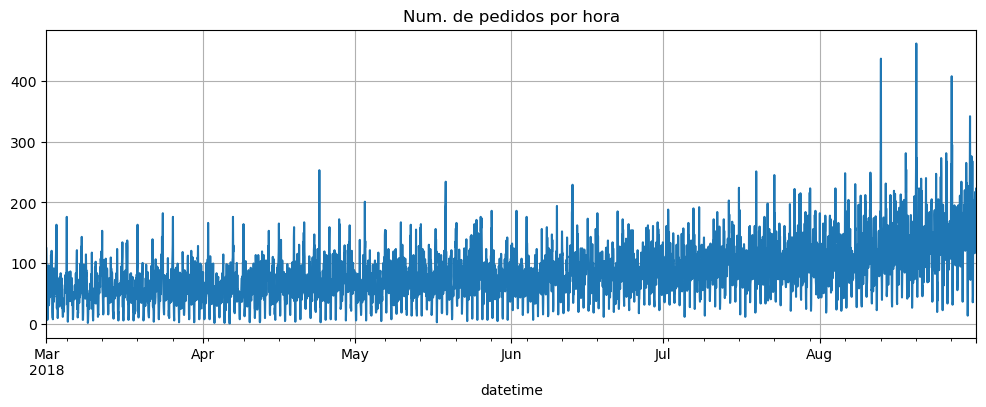

In [9]:
plt.figure(figsize=(12,4))
df['num_orders'].plot()
plt.title('Num. de pedidos por hora')
plt.grid(True)
plt.show()

Análise do gráfico — Número de pedidos por hora

- A série apresenta alta variação hora a hora, com diversos picos de demanda.
- Há uma tendência de crescimento gradual ao longo dos meses, principalmente a partir de maio.
- Apesar do ruído, é possível perceber que o nível médio da série aumenta — indicando tendência positiva.
- Esse comportamento sugere que fatores externos (como aumento no número de passageiros ou mudanças sazonais) influenciam na quantidade de pedidos.

### Rolling mean (média móvel)

In [10]:
df['rm_24']  = df['num_orders'].rolling(window=24, min_periods=1).mean()
df['rm_168'] = df['num_orders'].rolling(window=168, min_periods=1).mean()

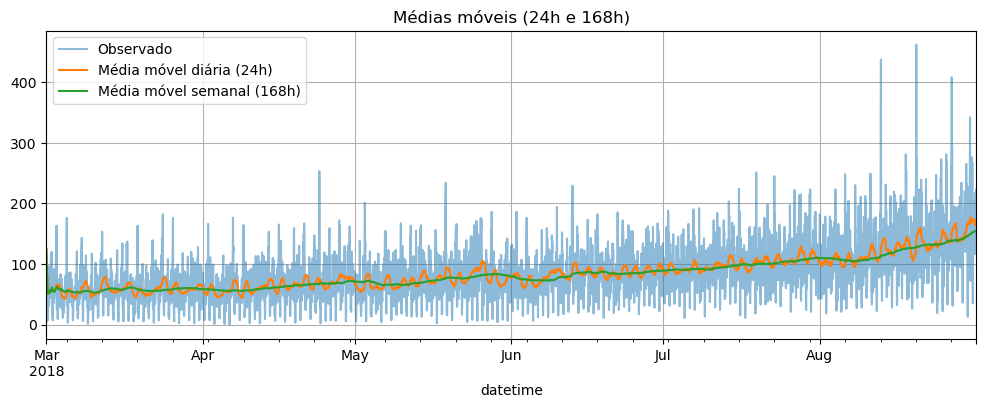

In [11]:
plt.figure(figsize=(12,4))
df['num_orders'].plot(alpha=0.5, label='Observado')
df['rm_24'].plot(label='Média móvel diária (24h)')
df['rm_168'].plot(label='Média móvel semanal (168h)')
plt.title('Médias móveis (24h e 168h)')
plt.legend()
plt.grid(True)
plt.show()

Análise do gráfico — Médias móveis (24h e 168h)

- A linha da média móvel de 24h suaviza as flutuações horárias, revelando o padrão diário de demanda.
- A média móvel de 168h (equivalente a uma semana) evidencia uma tendência de crescimento mais lenta e consistente ao longo do tempo.
- A combinação dessas médias mostra que existem padrões sazonais de curto prazo (diários) e uma tendência de longo prazo (semanal e mensal).

### Tendência, sazonalidade e resíduos

In [12]:
decomposed = seasonal_decompose(df['num_orders'])

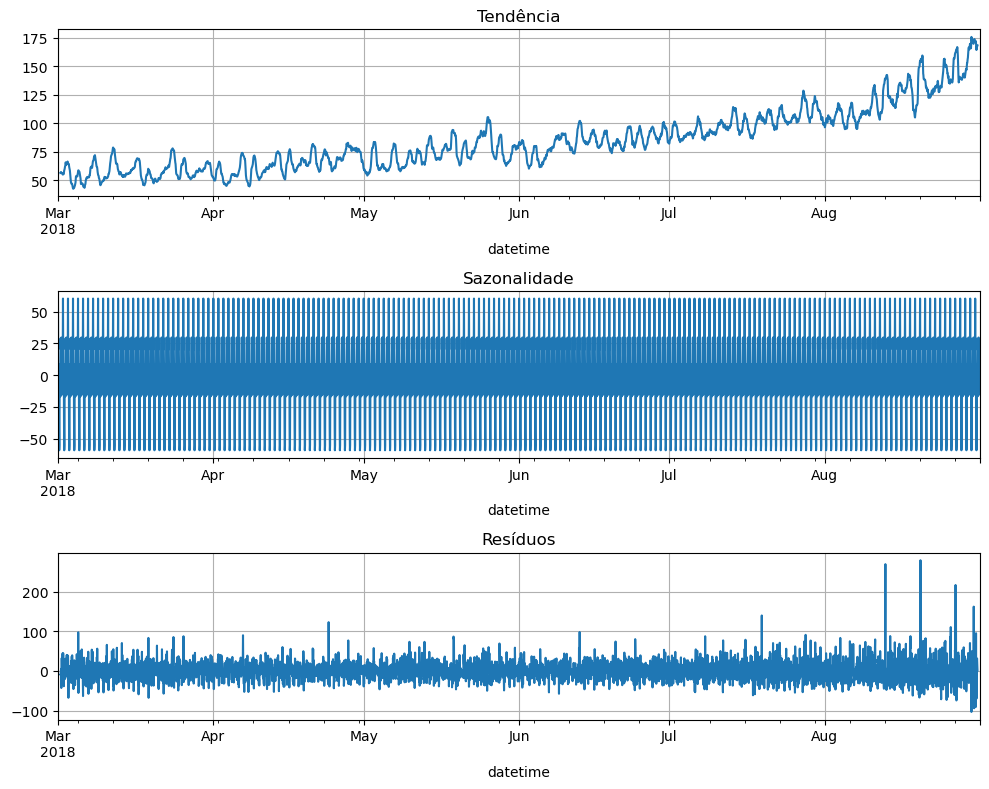

In [13]:
plt.figure(figsize=(10, 8))

plt.subplot(311)
decomposed.trend.plot(ax=plt.gca())
plt.title('Tendência')
plt.grid(True)
plt.subplot(312)
decomposed.seasonal.plot(ax=plt.gca())
plt.title('Sazonalidade')
plt.grid(True)
plt.subplot(313)
decomposed.resid.plot(ax=plt.gca())
plt.title('Resíduos')
plt.grid(True)
plt.tight_layout()

Análise da decomposição da série temporal

- Tendência:  
  Observa-se uma elevação gradual na demanda de táxis a partir de março, intensificando-se até agosto.  
  Esse crescimento indica uma tendência positiva no número médio de pedidos, possivelmente relacionada ao aumento de passageiros nos aeroportos ou à sazonalidade do período.  
  Esse componente mostra que a série não é estacionária, ou seja, o valor médio muda com o tempo.

- Sazonalidade:  
  A componente sazonal apresenta oscilações regulares e repetitivas, típicas de uma sazonalidade diária (periodicidade de 24 horas).  
  Isso indica que há padrões cíclicos previsíveis — certos horários do dia apresentam picos de demanda, enquanto outros registram quedas.  
  Esses padrões também podem se repetir semanalmente, refletindo o comportamento de dias úteis e fins de semana.

- Resíduos: 
  Os resíduos representam a parte da série não explicada pela tendência nem pela sazonalidade.  
  A maioria dos valores está próxima de zero, mas há picos pontuais — provavelmente causados por fatores externos imprevisíveis (chuvas, feriados, eventos, etc.).  
  Esses picos constituem o ruído aleatório, que não pode ser modelado diretamente.

Conclusão:  
A decomposição confirma que a série de pedidos de táxi combina uma tendência crescente com padrões sazonais diários e semanais bem definidos, além de variação aleatória residual.

## Treinamento

### Criando novas features para o modelo

#### Features de calendário

In [14]:
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

#### Features de defasagem (lags)

In [15]:
for lag in [1, 2, 3, 24, 168]:
    df[f'lag_{lag}'] = df['num_orders'].shift(lag)

#### Médias móveis (rolling means)

In [16]:
df['roll_3'] = df['num_orders'].shift(1).rolling(3).mean()     # média das últimas 3 horas
df['roll_24'] = df['num_orders'].shift(1).rolling(24).mean()   # média diária
df['roll_168'] = df['num_orders'].shift(1).rolling(168).mean() # média semanal

### Treinando os modelos

In [17]:
df['rm_24']  = df['num_orders'].shift(1).rolling(24).mean()
df['rm_168'] = df['num_orders'].shift(1).rolling(168).mean()

In [18]:
df = df.dropna()

In [19]:
target = 'num_orders'
features = [col for col in df.columns if col != target]
X = df[features]
y = df[target]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, shuffle=False)

In [21]:
tscv = TimeSeriesSplit(n_splits=5)

In [22]:
rmse_scorer = 'neg_root_mean_squared_error'

In [23]:
# Regressão linear
lr = LinearRegression()
lr_cv_scores = cross_val_score(lr, X_train, y_train, cv=tscv, scoring=rmse_scorer, n_jobs=-1)
lr_cv_rmse_mean = -np.mean(lr_cv_scores)
print(f"[CV] Regressão linear | RMSE médio (val): {lr_cv_rmse_mean:.2f}")

[CV] Regressão linear | RMSE médio (val): 23.41


In [24]:
# Floresta aleatória com diferentes hiperparâmetros
param_dist = {
    "n_estimators":  [150, 200, 300, 400, 500],
    "max_depth":     [8, 10, 12, 15, 18, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring=rmse_scorer,
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    refit=True,
    verbose=0
)

rf_search.fit(X_train, y_train)

rf_cv_rmse_mean = -rf_search.best_score_
print(f"[CV] Floresta aleatória | RMSE médio (val): {rf_cv_rmse_mean:.2f}")
print(f"Melhores hiperparâmetros (CV): {rf_search.best_params_}")

[CV] Floresta aleatória | RMSE médio (val): 23.58
Melhores hiperparâmetros (CV): {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 10}


In [25]:
if lr_cv_rmse_mean <= rf_cv_rmse_mean:
    best_name_cv = "Regressão linear"
    best_estimator_cv = LinearRegression()
    best_cv_rmse = lr_cv_rmse_mean
else:
    best_name_cv = "Floresta aleatória"
    best_estimator_cv = rf_search.best_estimator_
    best_cv_rmse = rf_cv_rmse_mean

print(f"Melhor na validação (TimeSeriesSplit): {best_name_cv} | RMSE médio: {best_cv_rmse:.2f}")

Melhor na validação (TimeSeriesSplit): Regressão linear | RMSE médio: 23.41


## Testando

In [28]:
best_model = best_estimator_cv
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
best_rmse = mean_squared_error(y_test, y_pred) ** 2

print(f"Melhor modelo final (pela validação): {best_name_cv} | RMSE no teste: {best_cv_rmse:.2f}")

Melhor modelo final (pela validação): Regressão linear | RMSE no teste: 23.41


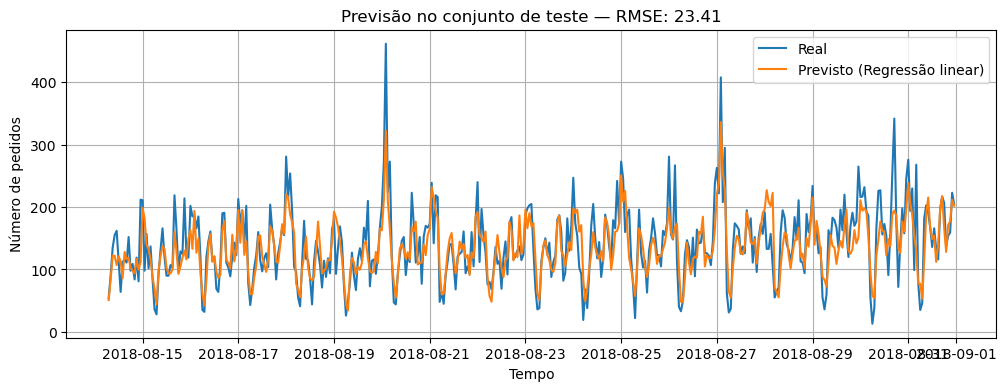

In [29]:
plt.figure(figsize=(12, 4))
plt.plot(y_test.index, y_test.values, label="Real")
plt.plot(y_test.index, y_pred, label=f"Previsto ({best_name_cv})")
plt.title(f"Previsão no conjunto de teste — RMSE: {best_cv_rmse:.2f}")
plt.xlabel("Tempo")
plt.ylabel("Número de pedidos")
plt.legend()
plt.grid(True)
plt.show()

## Conclusão

Após a análise e o treinamento dos modelos:

- Regressão Linear obteve RMSE = 23.40, superando a meta do projeto (≤ 48).  
- Floresta Aleatória apresentou RMSE médio de 23.58, quase superando o modelo linear, mas ainda ficando atrás.  

A regressão linear se mostrou mais eficaz por capturar diretamente os padrões de tendência e sazonalidade horária/diária.

As features de defasagem (lags) e médias móveis (rollings) foram essenciais para descrever o comportamento temporal.

A Regressão Linear foi avaliada por validação cruzada simples.

A Floresta Aleatória foi otimizada com RandomizedSearchCV, utilizando a métrica RMSE (neg_root_mean_squared_error) e o mesmo TimeSeriesSplit como estratégia de validação.

O modelo final, portanto, é a regressão linear, capaz de prever com boa precisão a demanda horária por táxis, com erro médio dentro do limite solicitado.

# Revisão da checklist

- [x]  O Jupyter Notebook está aberto.
- [x]  O código está livre de erros
- [x]  As células com o código foram organizadas em ordem de execução.
- [x]  Os dados foram baixados e preparados
- [x]  Os dados foram analisados
- [x]  O modelo foi treinado e os hiperparâmetros foram selecionados
- [x]  O modelo foi avaliado. Uma conclusão foi fornecida
- [x]  O REQM para o conjunto de teste não é maior que 48